 # Linear Regression From Scratch: Implementation and Validation

## Introduction

This notebook complements the theoretical derivation of Ordinary Least Squares (OLS) Linear Regression by translating the analytical formulation into a concrete implementation.

The objective is to reconstruct the regression model entirely from first principles and examine how its theoretical properties manifest in practice.

Specifically, this notebook focuses on:

- Computing regression parameters directly from analytical expressions  
- Visualizing the fitted model against observed data  
- Analyzing residual behavior to evaluate model adequacy  
- Examining squared error distribution to understand optimization effects  

The implementation avoids the use of external machine learning libraries for model training, ensuring that each step reflects the underlying mathematical formulation.

## Importing Libraries

This implementation relies on a small set of scientific computing and machine learning libraries.

- **NumPy** is used for numerical computation
- **Pandas** is included for possible dataset handling
- **Matplotlib** is used for visualization
- **Scikit-Learn** is used only to validate the correctness of the manual implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 1. Dataset Definition

To keep the first implementation simple and interpretable, we begin with a small manually defined dataset. This allows the regression calculations to be traced clearly without the added complexity of data cleaning or preprocessing.

The independent variable $X$ and dependent variable $y$ are defined as follows.

In [2]:
X = np.array([1,2,3,4,5], dtype=float)
y = np.array([2,4,5,4,5], dtype=float)
print("X: ",X)
print ("Y: ",y)

X:  [1. 2. 3. 4. 5.]
Y:  [2. 4. 5. 4. 5.]


##  2. Initial Data Visualization

Before fitting the regression model, it is useful to visualize the relationship between the input variable and the target variable.

A scatter plot provides an initial indication of whether a linear relationship exists, which justifies the use of a linear model.

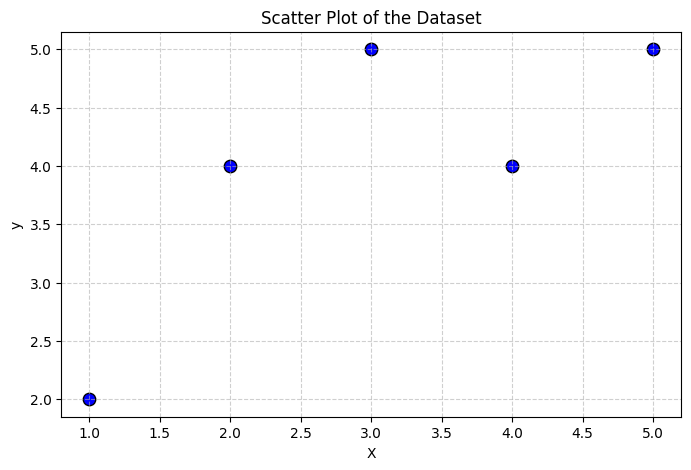

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", edgecolor="black", s=80)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter Plot of the Dataset")

plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("residual_plot.png") 
plt.show()

## 3. Computing Regression Coefficients

Using the closed-form expressions derived from the optimization of the Mean Squared Error, the parameters of the regression line can be computed directly from the observed data.

Slope:

$$
m = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}
$$

Intercept:

$$
b = \bar{y} - m\bar{x}
$$

These expressions allow us to compute the best-fitting regression line directly from the dataset.

In [4]:
#Compute mean values
x_mean=np.mean(X)
y_mean=np.mean(y)
print("Mean of X:",x_mean)
print ("Mean of y:",y_mean)

# Compute slope (m)
numerator = np.sum((X - x_mean)*(y - y_mean))
denominator = np.sum((X - x_mean) ** 2)
m=numerator/denominator

# Compute intercept (b)
b = y_mean - m * x_mean

print("Slope (m):", m)
print("Intercept (b):", b)

Mean of X: 3.0
Mean of y: 4.0
Slope (m): 0.6
Intercept (b): 2.2


## 4. Model Prediction

Once the regression coefficients have been computed, predictions can be generated using the linear model:

$$
\hat{y} = mx + b
$$

This equation produces the predicted value \( \hat{y} \) for a given input \( x \) using the estimated parameters.

In [5]:
y_pred = m * X + b
print("Predicted values:", y_pred)

Predicted values: [2.8 3.4 4.  4.6 5.2]


## 5. Plotting the Regression Line

After computing the predicted values, the fitted regression line can be plotted alongside the observed data points.

This visualization illustrates how well the linear model captures the underlying trend in the dataset.

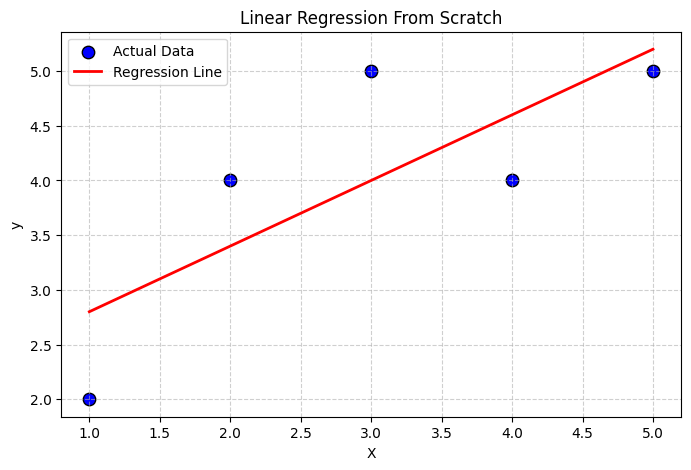

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="blue", edgecolor="black", s=80, label="Actual Data")
plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression From Scratch")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("regression_plot.png")
plt.show()

## 6. Residual Analysis

Residuals represent the difference between the observed values and the predicted values produced by the model.

$$
e_i = y_i - \hat{y}_i
$$

They provide insight into how well the model fits the data at each point.

In [7]:
# Calculate residuals
residuals = y - y_pred

print("Residuals:", residuals)

Residuals: [-0.8  0.6  1.  -0.6 -0.2]


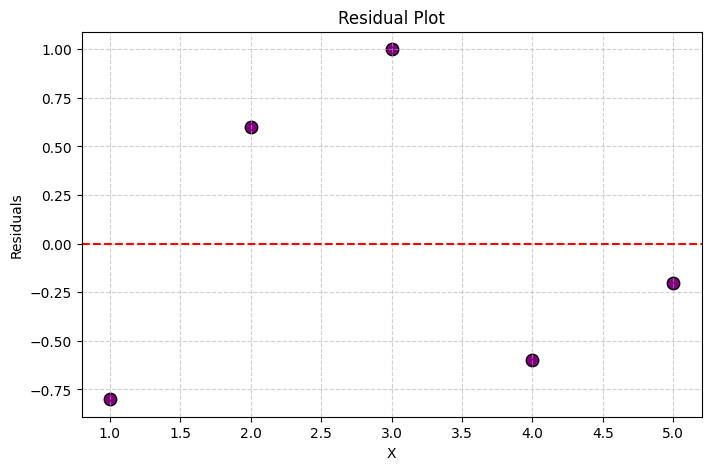

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(X, residuals, color="purple", edgecolor="black", s=80)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("X")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

The residuals appear to be distributed around zero without a strong systematic pattern. This suggests that the linear model provides a reasonable fit to the data, as no clear structure remains unexplained.

If the residuals exhibited a pattern (such as curvature), it would indicate that the linear model is insufficient.

## 7. Squared Error Analysis

Mean Squared Error (MSE) quantifies the average squared difference between the observed values and the predicted values:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

By squaring the residuals, larger errors are penalized more heavily than smaller ones, making MSE sensitive to significant deviations.

The computed MSE provides a measure of how well the regression line fits the data.

A lower value of MSE indicates that the predicted values are closer to the observed values, implying a better fit. However, since the dataset used here is small, the value should be interpreted cautiously and primarily serves as an illustration of error behavior.

## 8. Validation Against Standard Implementation

To verify the correctness of the manually derived and implemented solution, the regression parameters are compared with those obtained from a standard library implementation.

A linear regression model from Scikit-Learn is fitted on the same dataset, and the resulting coefficients are examined.

The close agreement between the manually computed parameters and those produced by the library implementation confirms the correctness of the analytical derivation and its implementation.

In [9]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 0.47999999999999987
R² Score: 0.6000000000000001


In [10]:
X_sklearn = X.reshape(-1, 1)

model = LinearRegression()
model.fit(X_sklearn, y)

y_pred_sklearn = model.predict(X_sklearn)

print("Scikit-Learn Slope:", model.coef_[0])
print("Scikit-Learn Intercept:", model.intercept_)
print("Scikit-Learn Predictions:", y_pred_sklearn)


Scikit-Learn Slope: 0.6
Scikit-Learn Intercept: 2.2
Scikit-Learn Predictions: [2.8 3.4 4.  4.6 5.2]


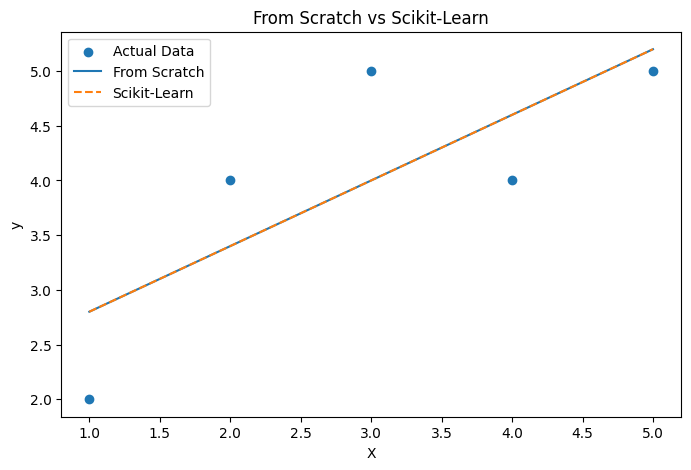

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, label="From Scratch")
plt.plot(X, y_pred_sklearn, linestyle="--", label="Scikit-Learn")
plt.xlabel("X")
plt.ylabel("y")
plt.title("From Scratch vs Scikit-Learn")
plt.legend()
plt.show()


## 9. Observations

This exercise demonstrates how linear regression can be constructed entirely from first principles by formulating it as an optimization problem.

The regression coefficients were derived analytically by minimizing the Mean Squared Error and then computed directly from the observed data without relying on external machine learning libraries.

Visualization of the fitted regression line indicates that the model captures the overall trend of the dataset effectively.

Residual analysis shows that the errors are distributed around zero without a clear systematic pattern, suggesting that the linear model is appropriate for this data.

The computed Mean Squared Error provides a quantitative measure of model fit, supporting the visual assessment.

Finally, comparison with a standard library implementation confirms that the manually derived and implemented solution is correct.

Overall, this study highlights the connection between statistical modeling and optimization, and demonstrates how foundational machine learning models can be understood, derived, and validated from first principles.